In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

print('✅ Dataset loaded!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head(10)

✅ Dataset loaded!
Shape: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
print('📊 Dataset Info:')
df.info()
print('\n📈 Statistical Summary:')
display(df.describe())

print('\n❓ Missing Values:')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print(f'\n🔁 Duplicate Rows: {df.duplicated().sum()}')

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

📈 Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



❓ Missing Values:
          Missing Count  Missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467

🔁 Duplicate Rows: 0


In [4]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle outliers (IQR method)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
df['Fare'] = df['Fare'].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                labels=['Child','Teen','Young Adult','Adult','Senior'])

print('✅ Data Cleaned Successfully!')
print(f'Final shape: {df.shape}')

✅ Data Cleaned Successfully!
Final shape: (891, 14)


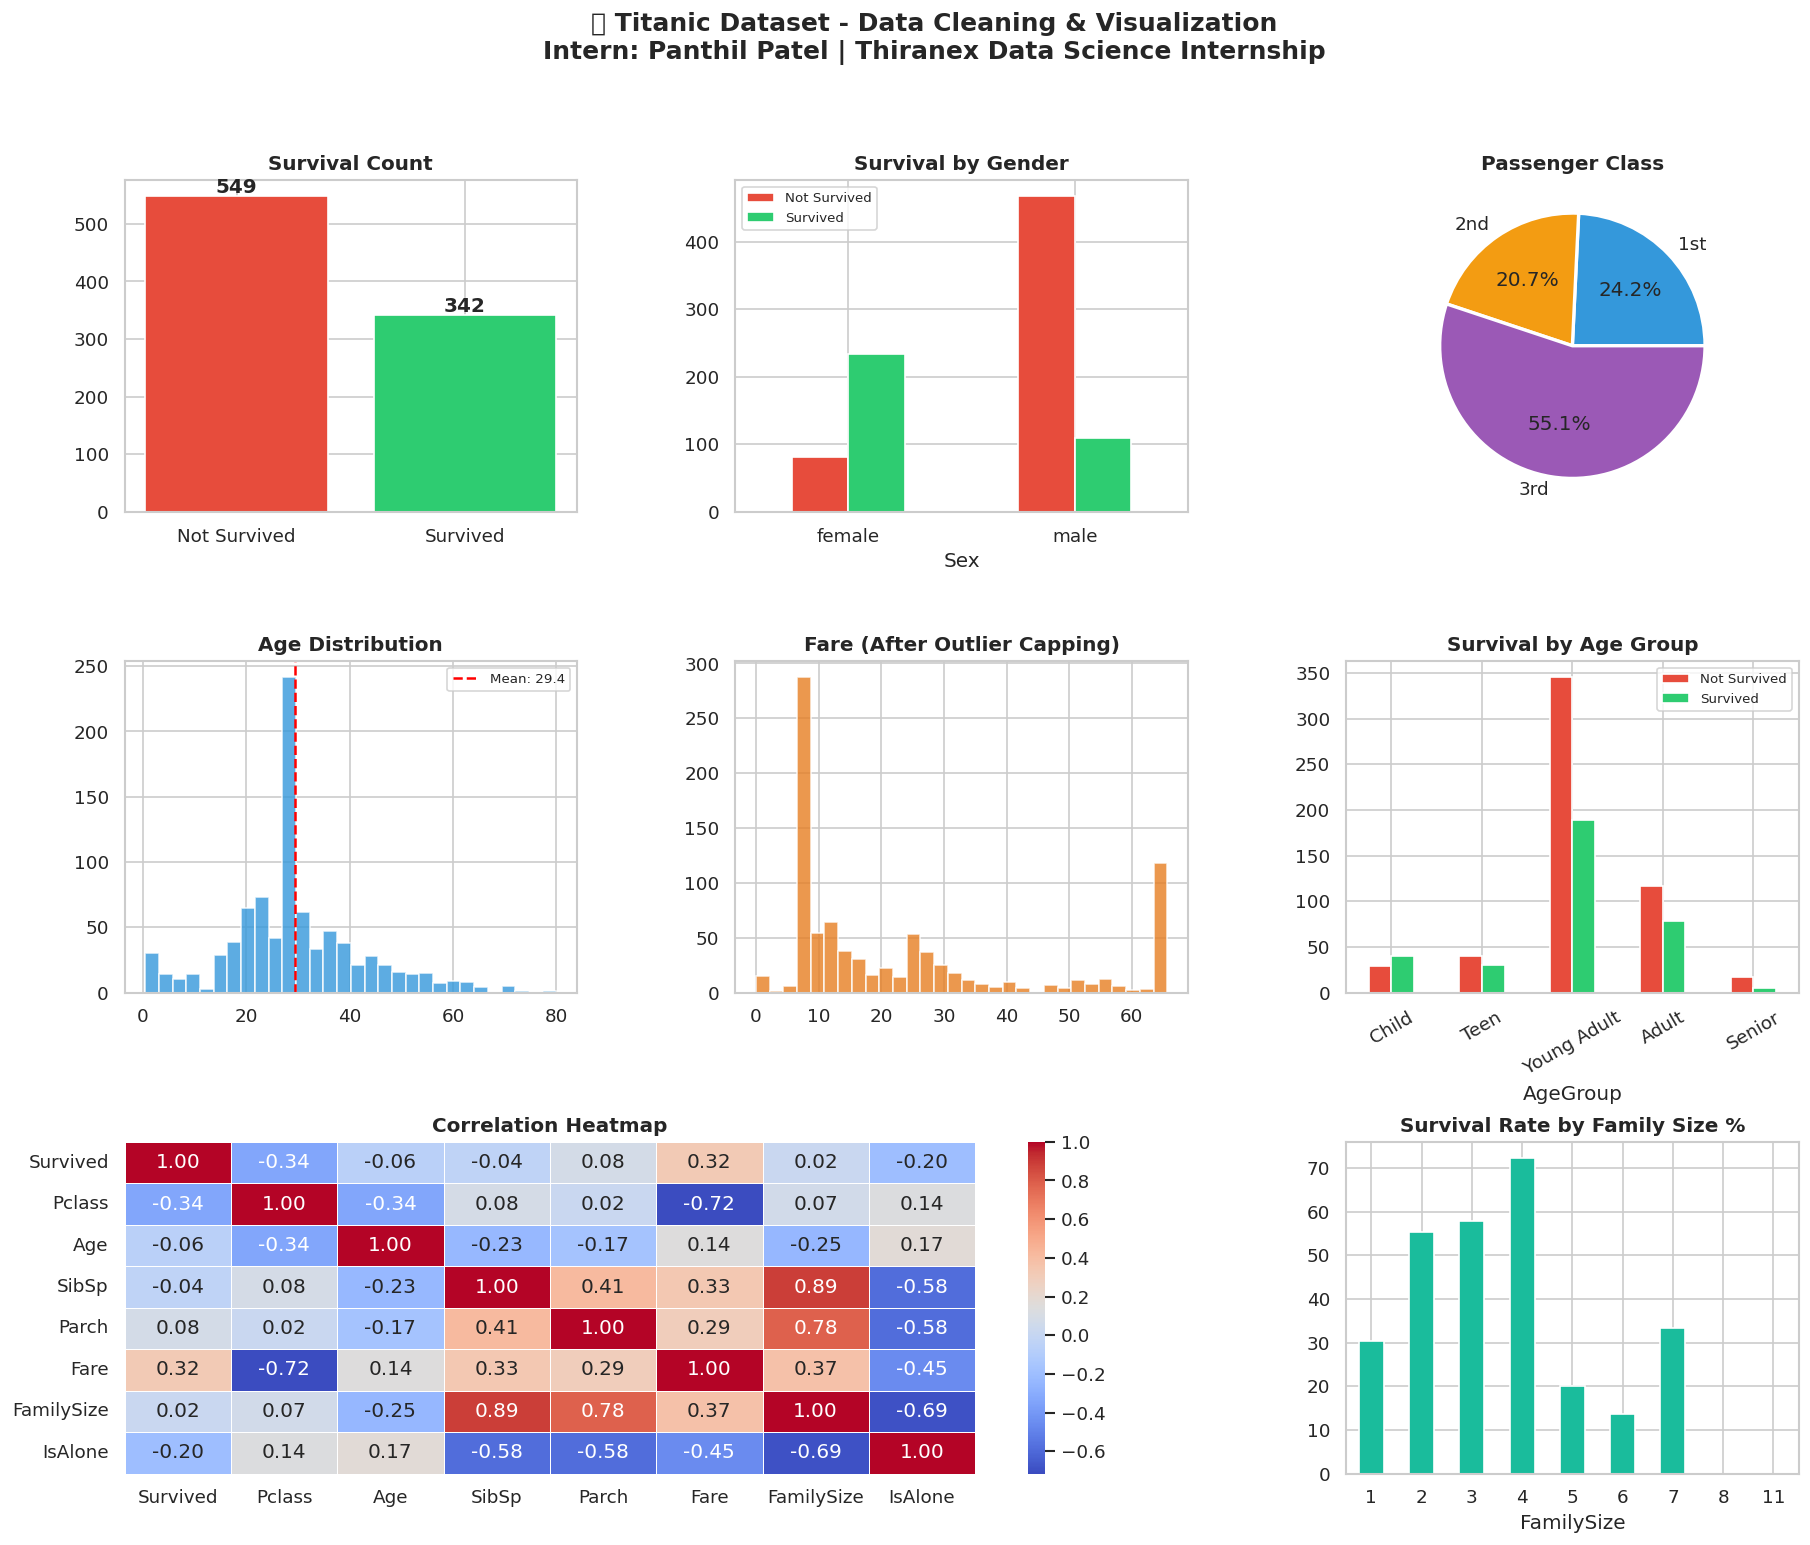

✅ Dashboard saved!


In [5]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('🚢 Titanic Dataset - Data Cleaning & Visualization\nIntern: Panthil Patel | Thiranex Data Science Internship',
             fontsize=15, fontweight='bold')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Survival Count
ax1 = fig.add_subplot(gs[0, 0])
survival_counts = df['Survived'].value_counts()
ax1.bar(['Not Survived', 'Survived'], survival_counts.values,
        color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax1.set_title('Survival Count', fontweight='bold')
for i, v in enumerate(survival_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Survival by Gender
ax2 = fig.add_subplot(gs[0, 1])
df.groupby(['Sex','Survived']).size().unstack().plot(
    kind='bar', ax=ax2, color=['#e74c3c','#2ecc71'], rot=0)
ax2.set_title('Survival by Gender', fontweight='bold')
ax2.legend(['Not Survived','Survived'], fontsize=8)

# 3. Class Distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.pie(df['Pclass'].value_counts().sort_index(),
        labels=['1st','2nd','3rd'], autopct='%1.1f%%',
        colors=['#3498db','#f39c12','#9b59b6'],
        wedgeprops={'edgecolor':'white','linewidth':2})
ax3.set_title('Passenger Class', fontweight='bold')

# 4. Age Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['Age'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax4.axvline(df['Age'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Age"].mean():.1f}')
ax4.set_title('Age Distribution', fontweight='bold')
ax4.legend(fontsize=8)

# 5. Fare Distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df['Fare'], bins=30, color='#e67e22', edgecolor='white', alpha=0.8)
ax5.set_title('Fare (After Outlier Capping)', fontweight='bold')

# 6. Survival by Age Group
ax6 = fig.add_subplot(gs[1, 2])
df.groupby(['AgeGroup','Survived']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax6, color=['#e74c3c','#2ecc71'], rot=30)
ax6.set_title('Survival by Age Group', fontweight='bold')
ax6.legend(['Not Survived','Survived'], fontsize=8)

# 7. Correlation Heatmap
ax7 = fig.add_subplot(gs[2, 0:2])
cols = ['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize','IsAlone']
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax7, linewidths=0.5)
ax7.set_title('Correlation Heatmap', fontweight='bold')

# 8. Family Size vs Survival
ax8 = fig.add_subplot(gs[2, 2])
df.groupby('FamilySize')['Survived'].mean().mul(100).plot(
    kind='bar', ax=ax8, color='#1abc9c', edgecolor='white', rot=0)
ax8.set_title('Survival Rate by Family Size %', fontweight='bold')

plt.savefig('Project1_Dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Dashboard saved!')

In [6]:
df.to_csv('Titanic_Cleaned.csv', index=False)

# Download files
from google.colab import files
files.download('Titanic_Cleaned.csv')
files.download('Project1_Dashboard.png')

print('✅ Files downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!
